<a href="https://colab.research.google.com/github/550tealeaves/DATA-70500-working-with-data/blob/main/NBA_Season_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
# Install NBA data library
!pip install nba_api --quiet
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sqlite3

from nba_api.stats.endpoints import leagueleaders, leaguestandingsv3
from nba_api.stats.static import teams
import time

## Pull player stats for current season

In [2]:
# Fetch player stats from NBA.com
#StatCategory options: PTS, REB, AST, STL, BLK, FG_PCT, FT_PCT, FG3_PCT
stats = leagueleaders.LeagueLeaders(
    season = '2025-26',
    stat_category_abbreviation='PTS',
    per_mode48='PerGame'
)

# Convert to a pandas DataFrame]
df_players = stats.get_data_frames()[0]

#Preview the columns & first rows
print(df_players.columns.tolist())
print(df_players.head())

['PLAYER_ID', 'RANK', 'PLAYER', 'TEAM_ID', 'TEAM', 'GP', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PTS', 'EFF']
   PLAYER_ID  RANK                   PLAYER     TEAM_ID TEAM  GP   MIN   FGM  \
0    1629029     1              Luka Dončić  1610612747  LAL  62  36.0  10.9   
1    1628983     2  Shai Gilgeous-Alexander  1610612760  OKC  62  33.4  10.9   
2    1630162     3          Anthony Edwards  1610612750  MIN  58  35.5  10.1   
3    1630178     4             Tyrese Maxey  1610612755  PHI  62  38.3  10.1   
4    1627759     5             Jaylen Brown  1610612738  BOS  65  34.3  10.3   

    FGA  FG_PCT  ...  FT_PCT  OREB  DREB  REB  AST  STL  BLK  TOV   PTS   EFF  
0  22.9   0.476  ...   0.776   0.7   7.2  7.8  8.2  1.6  0.5  4.0  33.7  33.7  
1  19.6   0.553  ...   0.884   0.5   3.9  4.4  6.6  1.4  0.8  2.1  31.4  32.6  
2  20.5   0.492  ...   0.796   0.6   4.5  5.1  3.7  1.4  0.8  2.8  29.5  25

## Pull team standings & load both tables into SQLite

In [3]:
# Fetch current team standings
standings_raw = leaguestandingsv3.LeagueStandingsV3(season='2025-26')
df_standings = standings_raw.get_data_frames()[0]

# Keep only the most useful columns
df_standings = df_standings[[
    'TeamCity', 'TeamName', 'Conference', 'Division',
    'WINS', 'LOSSES', 'WinPCT', 'HOME', 'ROAD',
    'L10', 'CurrentStreak', 'strCurrentStreak'
]]

# Load both tables into SQLite
conn = sqlite3.connect(':memory:')
df_players.to_sql('players', conn, index=False, if_exists='replace')
df_standings.to_sql('standings', conn, index=False, if_exists='replace')

print('Players table rows:', pd.read_sql_query('SELECT COUNT(*) FROM players', conn).iloc[0,0])
print('Standings table rows:', pd.read_sql_query('SELECT COUNT(*) FROM standings', conn).iloc[0,0])

Players table rows: 247
Standings table rows: 30


## Convert to CSV and download (ran this in SQLite to make sure syntax was correct)

In [ ]:
# Convert to CSV & download
df_players.to_csv('df_players.csv', index=False)
df_standings.to_csv('df_standings.csv', index=False)
from google.colab import files
files.download('df_players.csv')
files.download('df_standings.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Run week 1 inspection commands in new data
- Always inspect both tables before writing SQL

In [4]:
# Inspect the players table
print('--- PLAYERS ---')
print(df_players.shape)
print(df_players.info())
print(df_players.describe())

# Inspect the standings table
print('--- STANDINGS ---')
print(df_standings.shape)
print(df_standings.info())
print(df_standings.describe())

--- PLAYERS ---
(247, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   PLAYER_ID  247 non-null    int64  
 1   RANK       247 non-null    int64  
 2   PLAYER     247 non-null    object 
 3   TEAM_ID    247 non-null    int64  
 4   TEAM       247 non-null    object 
 5   GP         247 non-null    int64  
 6   MIN        247 non-null    float64
 7   FGM        247 non-null    float64
 8   FGA        247 non-null    float64
 9   FG_PCT     247 non-null    float64
 10  FG3M       247 non-null    float64
 11  FG3A       247 non-null    float64
 12  FG3_PCT    247 non-null    float64
 13  FTM        247 non-null    float64
 14  FTA        247 non-null    float64
 15  FT_PCT     247 non-null    float64
 16  OREB       247 non-null    float64
 17  DREB       247 non-null    float64
 18  REB        247 non-null    float64
 19  AST        247 non-null 

# New SQL skills

| New skill | Function | Example |
| :--- | :--- | :--- |
| AND / OR / NOT | Combine multiple conditions in 1 WHERE | Players scoring 20pts AND shooting 45%+ FG |
| BETWEEN | Filter range of values | Playesr w/ 10-20ppg |
| IN (...) | Match any value in a list | Players on LAL, BOS, or OKC |
| COALESCE | Replace NULL w/ fallback value | Show 0 instead of NULL for missing 3PT% |
| CASE WHEN | Create categories from numeric values | Label players as 'Star', 'Starter' or 'Role Player' based on pts |

In [5]:
# Example
# AND — two conditions must both be true
pd.read_sql_query('''
    SELECT PLAYER, TEAM, PTS, FG_PCT
    FROM players
    WHERE PTS >= 20 AND FG_PCT >= 0.45
    ORDER BY PTS DESC
''', conn)

# CASE WHEN — create a new label column
pd.read_sql_query('''
    SELECT PLAYER, TEAM, PTS,
           CASE
               WHEN PTS >= 25 THEN 'Star'
               WHEN PTS >= 15 THEN 'Starter'
               ELSE 'Role Player'
                          END AS player_tier
    FROM players
    ORDER BY PTS DESC
    LIMIT 20
''', conn)

# COALESCE — replace NULL with 0
pd.read_sql_query('''
    SELECT PLAYER, TEAM,
           COALESCE(FG3_PCT, 0) AS three_pt_pct
    FROM players
    LIMIT 20
''', conn)

,PLAYER,TEAM,three_pt_pct
0,Luka Dončić,LAL,0.366
1,Shai Gilgeous-Alexander,OKC,0.379
2,Anthony Edwards,MIN,0.402
3,Tyrese Maxey,PHI,0.374
4,Jaylen Brown,BOS,0.342
5,Kawhi Leonard,LAC,0.381
6,Nikola Jokić,DEN,0.385
7,Donovan Mitchell,CLE,0.365
8,Jalen Brunson,NYK,0.370
9,Kevin Durant,HOU,0.411


In [6]:
# CASE WHEN — create a new label column
pd.read_sql_query('''
    SELECT PLAYER, TEAM, PTS,
           CASE
               WHEN PTS >= 25 THEN 'Star'
               WHEN PTS >= 15 THEN 'Starter'
               ELSE 'Role Player'
                          END AS PLAYER_TIER
    FROM players
    ORDER BY PTS DESC
    LIMIT 20
''', conn)

,PLAYER,TEAM,PTS,PLAYER_TIER
0,Luka Dončić,LAL,33.7,Star
1,Shai Gilgeous-Alexander,OKC,31.4,Star
2,Anthony Edwards,MIN,29.5,Star
3,Tyrese Maxey,PHI,28.9,Star
4,Jaylen Brown,BOS,28.6,Star
5,Kawhi Leonard,LAC,28.3,Star
6,Nikola Jokić,DEN,27.9,Star
7,Donovan Mitchell,CLE,27.9,Star
8,Jalen Brunson,NYK,26.2,Star
9,Kevin Durant,HOU,26.0,Star


## 1. Write a query that finds all players averaging at least 20 points AND at least 5 assists per game. Sort by points descending. How many players qualify?
- 18 players qualify

In [7]:
pd.read_sql_query('''
    SELECT PLAYER, PTS, AST
    FROM players
    WHERE PTS >= 20 AND AST >= 5
    ORDER BY PTS DESC
''', conn)

,PLAYER,PTS,AST
0,Luka Dončić,33.7,8.2
1,Shai Gilgeous-Alexander,31.4,6.6
2,Tyrese Maxey,28.9,6.7
3,Jaylen Brown,28.6,5.2
4,Nikola Jokić,27.9,10.8
5,Donovan Mitchell,27.9,5.8
6,Jalen Brunson,26.2,6.7
7,Jamal Murray,25.5,7.2
8,Devin Booker,25.5,6.0
9,Cade Cunningham,24.5,9.9


## 2. Find all players who play for either the OKC Thunder (OKC), San Antonio Spurs (SAS), or Detroit Pistons (DET) — the three biggest surprises of the season. Use the IN keyword instead of writing three OR conditions. How do their individual stats compare?
- Now you can't say that the Thunder are a surprise, they are the defending champions
- Nor can you be surprised at the Spurs ascension; they strategically tanked for Wemby (same strategy that landed them Tim Duncan)
- The Pistons improved in 2 short years. In 2023-24, they were an abysmal last place in the Eastern Conference.

- Results return 30 players

  *   3 top 20 players
  *   Overall players in this group are average
  * Harrison Barnes is still in the league?




In [8]:
pd.read_sql_query('''
    SELECT *
    FROM players
    WHERE TEAM IN ('OKC', 'SAS', 'DET')
''', conn)

,PLAYER_ID,RANK,PLAYER,TEAM_ID,TEAM,GP,MIN,FGM,FGA,FG_PCT,...,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PTS,EFF
0,1628983,2,Shai Gilgeous-Alexander,1610612760,OKC,62,33.4,10.9,19.6,0.553,...,0.884,0.5,3.9,4.4,6.6,1.4,0.8,2.1,31.4,32.6
1,1630595,13,Cade Cunningham,1610612765,DET,61,34.4,8.7,18.9,0.461,...,0.814,0.9,4.7,5.6,9.9,1.5,0.9,3.7,24.5,27.3
2,1641705,15,Victor Wembanyama,1610612759,SAS,59,29.2,8.3,16.6,0.501,...,0.820,2.0,9.3,11.3,3.0,1.1,3.1,2.5,24.2,30.6
3,1631105,36,Jalen Duren,1610612765,DET,64,28.0,7.4,11.5,0.642,...,0.745,3.8,6.8,10.6,1.8,0.9,0.9,1.8,19.3,26.0
4,1628368,39,De'Aaron Fox,1610612759,SAS,64,31.1,7.1,14.6,0.488,...,0.762,0.6,3.2,3.8,6.3,1.2,0.3,2.3,18.8,19.6
5,1631096,48,Chet Holmgren,1610612760,OKC,63,29.2,6.3,11.4,0.552,...,0.798,1.9,7.0,8.9,1.7,0.5,1.9,1.5,17.1,22.7
6,1642264,55,Stephon Castle,1610612759,SAS,62,29.6,5.6,12.0,0.471,...,0.734,1.4,3.8,5.1,7.2,1.2,0.3,3.2,16.6,19.4
7,1630170,73,Devin Vassell,1610612759,SAS,59,30.4,5.0,11.4,0.443,...,0.812,0.6,3.3,3.8,2.5,0.9,0.4,0.9,14.2,14.2
8,202699,82,Tobias Harris,1610612765,DET,57,28.2,4.9,10.7,0.462,...,0.873,0.9,4.4,5.2,2.5,0.9,0.4,1.0,13.4,15.3
9,1629640,89,Keldon Johnson,1610612759,SAS,74,23.2,5.0,9.5,0.533,...,0.795,1.6,3.8,5.4,1.4,0.6,0.1,0.9,13.0,14.8


## 3. Create a new column called player_tier that labels players as 'Star' (25+ PPG), 'Starter' (15–24 PPG), 'Role Player' (8–14 PPG), or 'Bench' (under 8 PPG). Show player name, team, points, and the new tier column. Sort by points descending and LIMIT to 30 rows.

In [13]:
# CASE WHEN — create a new label column
pd.read_sql_query('''
    SELECT PLAYER, TEAM, PTS,
           CASE
               WHEN PTS >= 25 THEN 'Star'
               WHEN PTS BETWEEN 15 AND 24.9 THEN 'Starter'
               WHEN PTS BETWEEN 8 AND 14.9 THEN 'Role Player'
               ELSE 'Bench'
                          END AS PLAYER_TIER
    FROM players
    ORDER BY PTS DESC
    LIMIT 30
''', conn)

,PLAYER,TEAM,PTS,PLAYER_TIER
0,Luka Dončić,LAL,33.7,Star
1,Shai Gilgeous-Alexander,OKC,31.4,Star
2,Anthony Edwards,MIN,29.5,Star
3,Tyrese Maxey,PHI,28.9,Star
4,Jaylen Brown,BOS,28.6,Star
5,Kawhi Leonard,LAC,28.3,Star
6,Nikola Jokić,DEN,27.9,Star
7,Donovan Mitchell,CLE,27.9,Star
8,Jalen Brunson,NYK,26.2,Star
9,Kevin Durant,HOU,26.0,Star


## 4. Find any players where the 3-point percentage (FG3_PCT) is NULL. How many are there, and why do you think that might be? Then write a second query using COALESCE to replace those NULLs with 0, so no row is excluded from results.
* Looked at the data and there are no NULL values in this column (they have 0s)

In [10]:
pd.read_sql_query('''
    SELECT PLAYER, TEAM, FG3_PCT
    FROM players
    WHERE FG3_PCT = NULL
''', conn)

pd.read_sql_query('''
    SELECT PLAYER, TEAM, FG3_PCT, coalesce (FG3_PCT, 0) AS three_pt_pct
    FROM players
''', conn)

,PLAYER,TEAM,FG3_PCT,three_pt_pct
0,Luka Dončić,LAL,0.366,0.366
1,Shai Gilgeous-Alexander,OKC,0.379,0.379
2,Anthony Edwards,MIN,0.402,0.402
3,Tyrese Maxey,PHI,0.374,0.374
4,Jaylen Brown,BOS,0.342,0.342
...,...,...,...,...
242,Mohamed Diawara,NYK,0.400,0.400
243,Dwight Powell,DAL,0.333,0.333
244,Jamison Battle,TOR,0.422,0.422
245,Tyus Jones,DEN,0.277,0.277


## 5. Switch to the standings table. Use Python (not SQL) to filter to only Western Conference teams, then sort by WinPCT descending

In [11]:
# Filter rows to only the Western Conference
filtered_df = df_standings[df_standings['Conference'] == 'West']

# Sort by WinPCT descending
sorted_df = filtered_df.sort_values(by='WinPCT', ascending=False)

# Add column to count rows
#sorted_df['Rank'] = range(1, len(sorted_df) + 1)

# Display the sorted DataFrame
sorted_df

,TeamCity,TeamName,Conference,Division,WINS,LOSSES,WinPCT,HOME,ROAD,L10,CurrentStreak,strCurrentStreak
0,Oklahoma City,Thunder,West,Northwest,58,16,0.784,30-6,28-9,9-1,1,W 1
2,San Antonio,Spurs,West,Southwest,56,18,0.757,28-7,27-11,9-1,8,W 8
4,Los Angeles,Lakers,West,Pacific,48,26,0.649,24-12,24-14,9-1,2,W 2
7,Denver,Nuggets,West,Northwest,47,28,0.627,23-13,24-15,8-2,5,W 5
8,Minnesota,Timberwolves,West,Northwest,45,29,0.608,25-14,20-15,5-5,-1,L 1
11,Houston,Rockets,West,Southwest,44,29,0.603,25-10,19-19,5-5,1,W 1
13,Phoenix,Suns,West,Pacific,41,33,0.554,24-15,17-18,4-6,1,W 1
14,LA,Clippers,West,Pacific,38,36,0.514,21-15,17-21,6-4,4,W 4
16,Portland,Trail Blazers,West,Northwest,37,38,0.493,20-17,17-21,6-4,-1,L 1
18,Golden State,Warriors,West,Pacific,36,38,0.486,21-15,15-23,4-6,3,W 3


## 5a. Switch to the standings table. Use Python (not SQL) to filter to only Eastern Conference teams, then sort by WinPCT descending

In [49]:
# Filter rows to only the Eastern Conference
filtered_df_east = df_standings[df_standings['Conference'] == 'East']

# Sort by WinPCT descending
sorted_df_east = filtered_df_east.sort_values(by='WinPCT', ascending=False)

# Add column to count rows
#sorted_df['Rank'] = range(1, len(sorted_df) + 1)

# Display the sorted DataFrame
sorted_df_east

,TeamCity,TeamName,Conference,Division,WINS,LOSSES,WinPCT,HOME,ROAD,L10,CurrentStreak,strCurrentStreak
1,Detroit,Pistons,East,Central,54,20,0.730,28-9,25-11,8-2,2,W 2
3,Boston,Celtics,East,Atlantic,49,24,0.671,26-11,23-13,7-3,2,W 2
5,New York,Knicks,East,Atlantic,48,26,0.649,27-9,20-17,7-3,-1,L 1
6,Cleveland,Cavaliers,East,Central,46,28,0.622,24-14,22-14,7-3,1,W 1
9,Toronto,Raptors,East,Atlantic,41,32,0.562,20-16,21-16,5-5,1,W 1
10,Atlanta,Hawks,East,Southeast,42,33,0.560,22-16,20-17,8-2,1,W 1
12,Philadelphia,76ers,East,Atlantic,41,33,0.554,21-17,20-16,7-3,2,W 2
15,Orlando,Magic,East,Southeast,39,34,0.534,22-14,16-18,4-6,1,W 1
17,Miami,Heat,East,Southeast,39,35,0.527,23-14,16-21,4-6,-1,L 1
19,Charlotte,Hornets,East,Southeast,39,35,0.527,19-18,20-17,7-3,-1,L 1


## 6. Look at the current standings — OKC is 58–16 and Detroit is 53–20. Both are huge surprises this season. Write 2–3 sentences about what SQL question you'd want to ask next to understand why these teams are performing so well. Think about what data you'd need that isn't in the current tables.

- Admittedly, I have not paid much attention to the NBA in recent years, especially not since the Warriors' last championship.
- But I am not surprised that OKC is the top team; they are defending champions, after all. Unless SGA is injured and out for the season, this should not be surprising.
- Looking at the past years stats, Detroit's ascension is suprising. Since they were last in Eastern Conference in 2023-24, they had a fairly decent lottery pick. Gone are the days when the last team automatically received the first pick.
  * I assume they built through the draft and perhaps strategic trades.

  

1.   For SQL, we could look at what player positions have these teams improved upon and whether that was from drafting or trading?
2.   How do the new rules that require players to play minimum games in order to receive awards and distinction impacting how teams play? (The anti-load management)
3.  What is the average age of these teams compared to others? I believe that OKC is relatively young.


# **Visualizations**

## All NBA

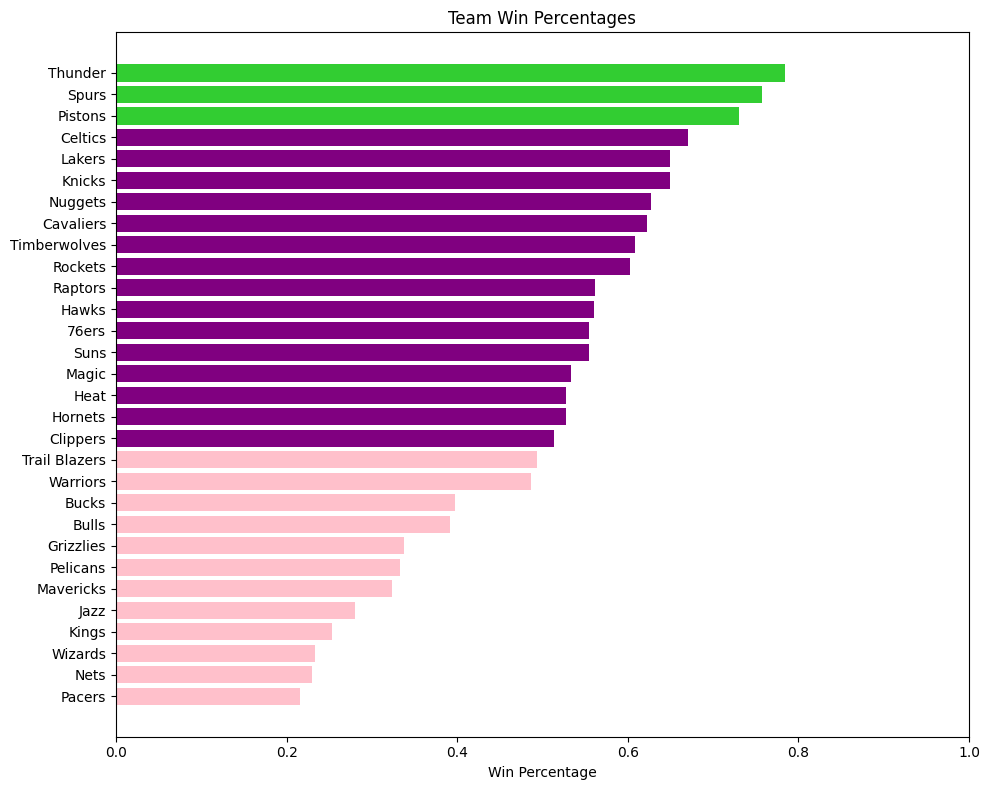

In [64]:
# HORIZONTAL BAR CHART

# Sort dataframe by win % in descending order
df_standings = df_standings.sort_values(by='WinPCT', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))

x = df_standings['TeamName']
y = df_standings['WinPCT']

# Define bar colors (will have 3 based on value)
colors = ['pink' if val <0.5 else 'purple' if 0.5 < val < 0.7 else 'limegreen' for val in y]

# Use 'x' (TeamName) for the y-axis and 'y' (WinPCT) for the bar lengths
hbars = ax.barh(x, y, align='center', color=colors)

# Set y-axis ticks and labels using team names
ax.set_yticks(x, labels=x)
ax.invert_yaxis()  # labels read top-to-bottom

ax.set_xlabel('Win Percentage')
ax.set_title('Team Win Percentages')

ax.set_xlim(right=1) # Win percentage goes from 0 to 1

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

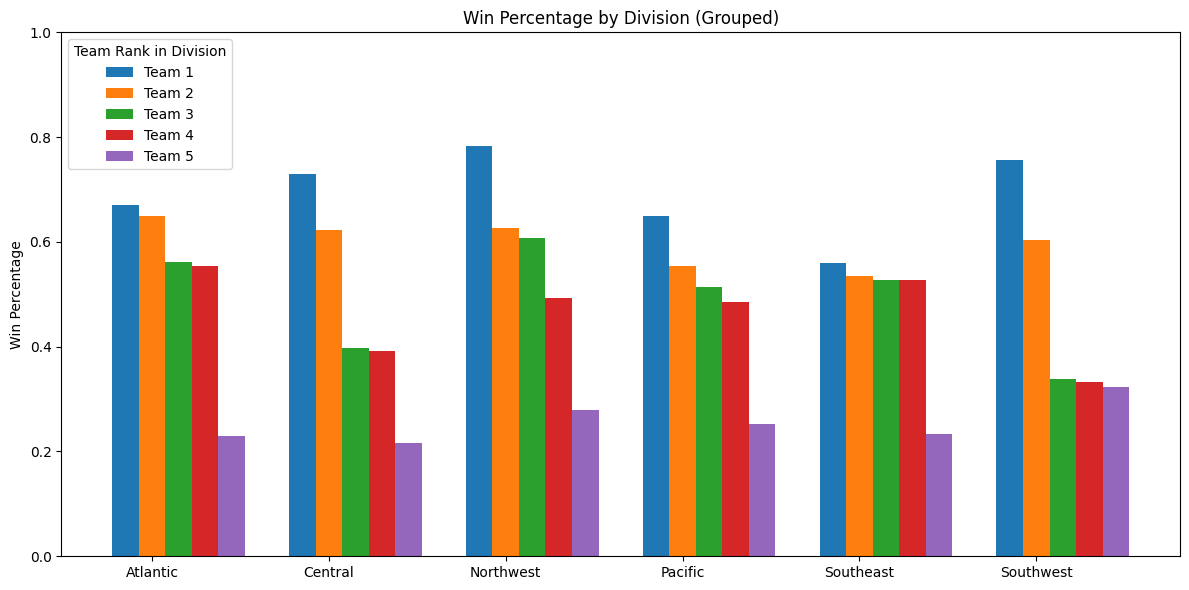

In [75]:
df_standings = df_standings.sort_values(['Division', 'WinPCT'], ascending=[True, False])

divisions = df_standings['Division'].unique()
teams_per_div = df_standings.groupby('Division').size().max()

bar_width = 0.15
x = np.arange(len(divisions))

fig, ax = plt.subplots(figsize=(12, 6))

for i in range(teams_per_div):
    values = []
    labels = []

    for div in divisions:
        group = df_standings[df_standings['Division'] == div]

        if i < len(group):
            values.append(group.iloc[i]['WinPCT'])
            labels.append(group.iloc[i]['TeamName'])
        else:
            values.append(0)
            labels.append('')

    ax.bar(x + i * bar_width, values, bar_width, label=f'Team {i+1}')

# Formatting
ax.set_xticks(x + bar_width)
ax.set_xticklabels(divisions)

ax.set_ylabel('Win Percentage')
ax.set_title('Win Percentage by Division (Grouped)')
ax.set_ylim(0, 1)

ax.legend(title='Team Rank in Division')
plt.tight_layout()
plt.show()

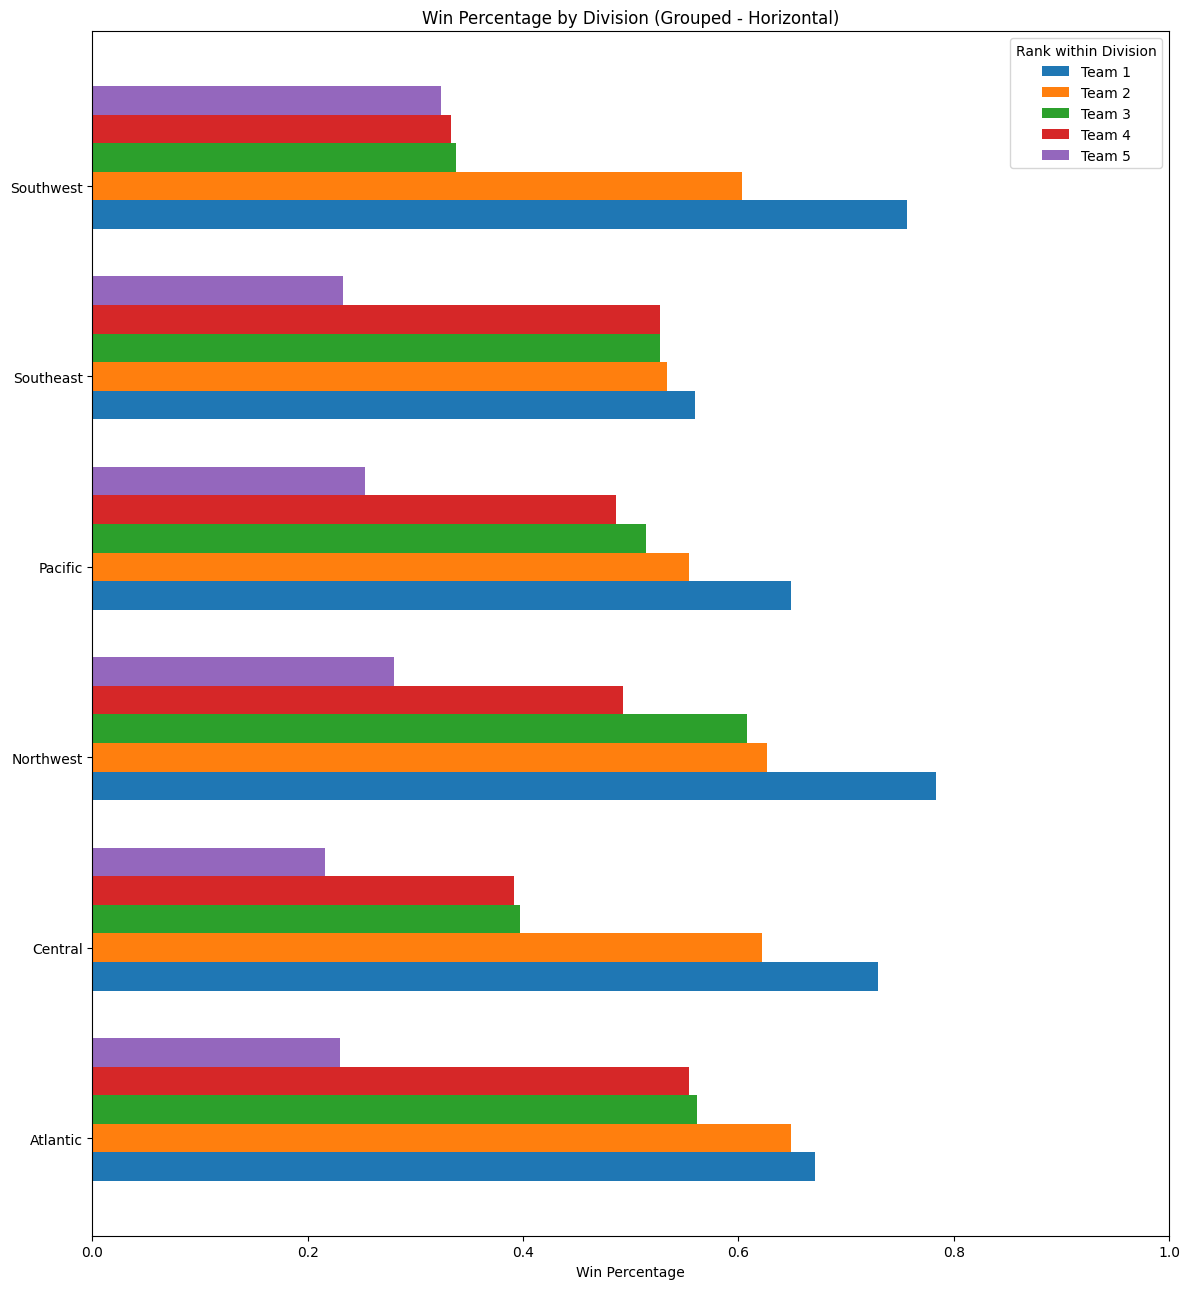

In [72]:
# Horizontal
# Sort within each division (best teams first)
df_standings = df_standings.sort_values(['Division', 'WinPCT'], ascending=[True, False])

divisions = df_standings['Division'].unique()
teams_per_div = df_standings.groupby('Division').size().max()

bar_height = 0.15
y = np.arange(len(divisions))

fig, ax = plt.subplots(figsize=(12, 13))

for i in range(teams_per_div):
    values = []

    for div in divisions:
        group = df_standings[df_standings['Division'] == div]

        if i < len(group):
            values.append(group.iloc[i]['WinPCT'])
        else:
            values.append(0)

    ax.barh(y + i * bar_height, values, height=bar_height, label=f'Team {i+1}')

# Labels & formatting
ax.set_yticks(y + bar_height)
ax.set_yticklabels(divisions)

ax.set_xlabel('Win Percentage')
ax.set_title('Win Percentage by Division (Grouped - Horizontal)')
ax.set_xlim(0, 1)

ax.legend(title='Rank within Division')

plt.tight_layout()
plt.show()

## Western Conference

### Bar chart

In [53]:
#VERTICAL BAR CHART
# plt.figure(figsize=(10, 10))
# x = sorted_df['TeamName']
# y = sorted_df['WinPCT']
# plt.bar(x, y, width=0.4, color='brown')
# plt

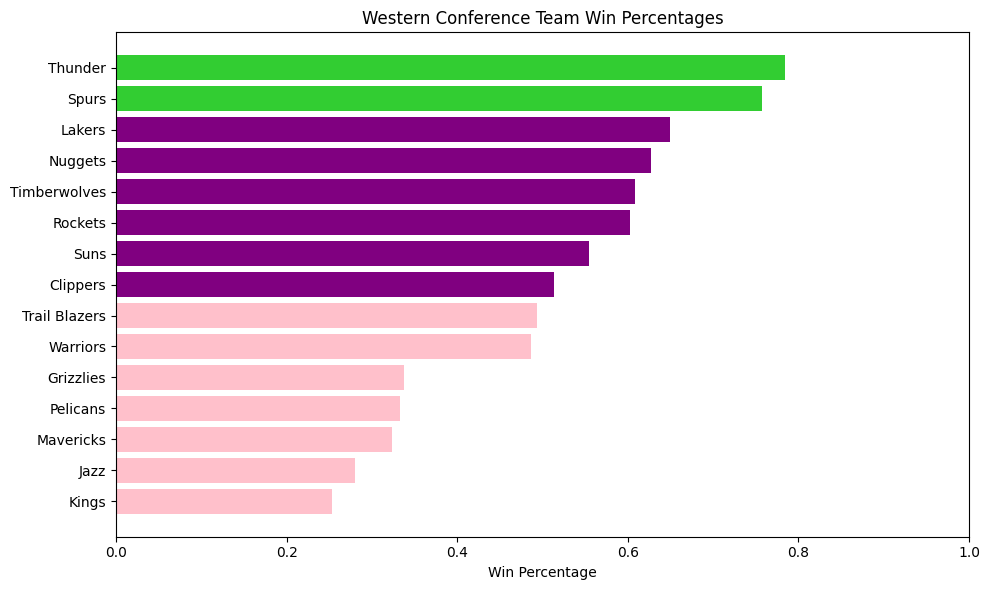

In [52]:
# HORIZONTAL BAR CHART
fig, ax = plt.subplots(figsize=(10, 6))

x = sorted_df['TeamName']
y = sorted_df['WinPCT']

# Define bar colors (will have 3 based on value)
colors = ['pink' if val <0.5 else 'purple' if 0.5 < val < 0.7 else 'limegreen' for val in y]

# Use 'x' (TeamName) for the y-axis and 'y' (WinPCT) for the bar lengths
hbars = ax.barh(x, y, align='center', color=colors)

# Set y-axis ticks and labels using team names
ax.set_yticks(x, labels=x)
ax.invert_yaxis()  # labels read top-to-bottom

ax.set_xlabel('Win Percentage')
ax.set_title('Western Conference Team Win Percentages')

ax.set_xlim(right=1) # Win percentage goes from 0 to 1



plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

## Eastern Conference

<Figure size 1000x1000 with 0 Axes>

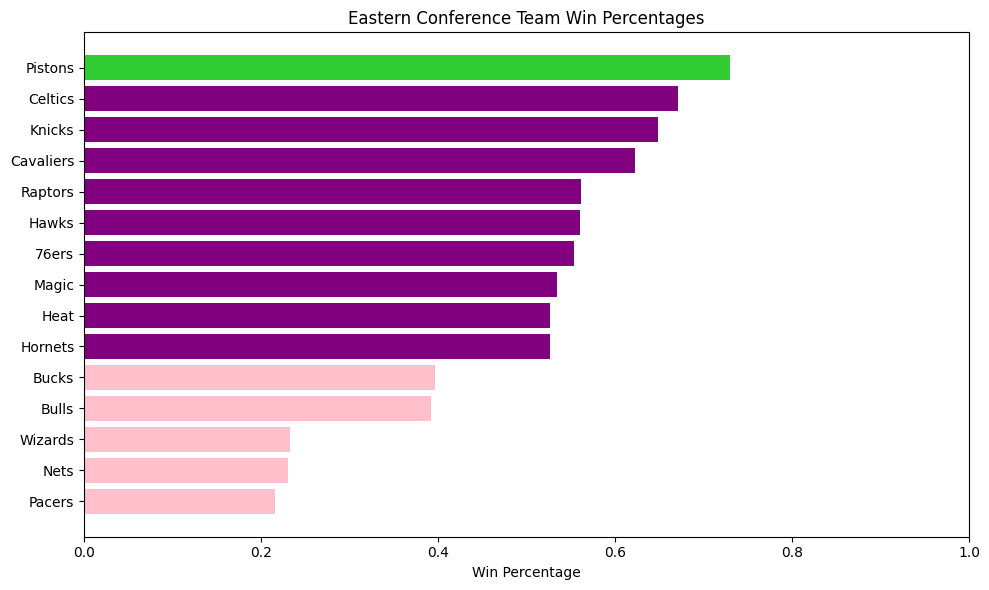

In [51]:
# HORIZONTAL BAR CHART
plt.figure(figsize=(10, 10))
x = sorted_df_east['TeamName']
y = sorted_df_east['WinPCT']

fig, ax = plt.subplots(figsize=(10, 6))

# Define bar colors (will have 3 based on value)
colors = ['pink' if val <0.5 else 'purple' if 0.5 < val < 0.7 else 'limegreen' for val in y]

# Use 'x' (TeamName) for the y-axis and 'y' (WinPCT) for the bar lengths
hbars = ax.barh(x, y, align='center', color=colors)

# Set y-axis ticks and labels using team names
ax.set_yticks(x, labels=x)
ax.invert_yaxis()  # labels read top-to-bottom

ax.set_xlabel('Win Percentage')
ax.set_title('Eastern Conference Team Win Percentages')

ax.set_xlim(right=1) # Win percentage goes from 0 to 1



plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()